In [1]:
import pandas as pd
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

# Common imports
import numpy as np
import os

import matplotlib as mpl
import matplotlib.pyplot as plt



### Følgene kode lager test set og treninigs set har gjort om til ratios men funket ikke så bra tror jeg

In [2]:
file_path = "C:/Users/benny/Documents/ML/MLing/dataset/concrete_data.csv"

if os.path.exists(file_path):                  #If statement for å laste inn datasettet 
    concrete_data = pd.read_csv(file_path)       #Datasetter har navnet cement_data
    #print(cement_data.head())
else:
    print("File not found!")



#print("Total duplicate rows in original dataset:", concrete_data.duplicated().sum()) se etter duplikate rader. er 25 må passe på!

concrete_data = concrete_data.drop_duplicates(subset=concrete_data.columns.difference(["Strength"])).reset_index(drop=True)
#concrete_data["Total"] = concrete_data["Cement"] + concrete_data["Water"] + concrete_data["Fly Ash"] + concrete_data["Blast Furnace Slag"] + concrete_data["Superplasticizer"] + concrete_data["Coarse Aggregate"] + concrete_data["Fine Aggregate"]
#concrete_data["Cment_water_ratio"] = concrete_data["Cement"] / concrete_data["Water"]
#concrete_data["Blast Furnace Slag to age ratio"] =  concrete_data["Blast Furnace Slag"]  


#Gjør datasettet om til ratios----------------------------------------------------------------------
def apply_ratio_transformation(df):
    df["Total"] = df["Cement"] + df["Water"] + df["Fly Ash"] + df["Blast Furnace Slag"] + df["Superplasticizer"] + df["Coarse Aggregate"] + df["Fine Aggregate"]
    for feature in ["Cement", "Water", "Fly Ash", "Blast Furnace Slag", "Superplasticizer", "Coarse Aggregate", "Fine Aggregate"]:
        df[feature + "_ratio"] = df[feature] / df["Total"]
        df.drop(columns=[feature], inplace=True)
    return df.drop(columns=["Total"])  
 
##--------------------------------------------------------------------------------------------------

#print(min(concrete_data["Strength"]), max(concrete_data["Strength"]))

#concrete_data["Age_cat"] = np.ceil(concrete_data["Age"] / 10)                   #lager stratiation treningssett slik at fordelingen av data i--
#concrete_data["Age_cat"].where(concrete_data["Age_cat"] < 5, 5.0, inplace=True)  #Test sett er lik i treningsett, er rar fremgang, se boken

# Step 1: Create Strength bins
num_strength_bins = 5  # Reduce this to 4 if needed
strength_bins = np.linspace(concrete_data["Strength"].min(), concrete_data["Strength"].max(), num_strength_bins + 1)
strength_labels = list(range(1, num_strength_bins + 1))
concrete_data["Strength_cat"] = pd.cut(concrete_data["Strength"], bins=strength_bins, labels=strength_labels, include_lowest=True)

# Step 2: Create Age bins
num_age_bins = 5  # Reduce this to 4 if needed
age_bins = np.linspace(concrete_data["Age"].min(), concrete_data["Age"].max(), num_age_bins + 1)
age_labels = list(range(1, num_age_bins + 1))
concrete_data["Age_cat"] = pd.cut(concrete_data["Age"], bins=age_bins, labels=age_labels, include_lowest=True)

# Step 3: Combine Strength & Age into a single categorical variable
concrete_data["Strength_Age_cat"] = concrete_data["Strength_cat"].astype(str) + "_" + concrete_data["Age_cat"].astype(str)

# Count occurrences of each category
category_counts = concrete_data["Strength_Age_cat"].value_counts()

# Identify rare categories (those with < 5 samples)
rare_categories = category_counts[category_counts < 5].index
print(f"Rare categories: {rare_categories.tolist()}")

# Find the most common category to merge rare ones into
most_common_category = category_counts.idxmax()

# Replace rare categories with the most common category (instead of using "Other")
concrete_data["Strength_Age_cat"] = concrete_data["Strength_Age_cat"].replace(rare_categories, most_common_category)

# Convert categorical labels to numerical values
concrete_data["Strength_Age_cat"] = concrete_data["Strength_Age_cat"].astype("category").cat.codes



split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(concrete_data, concrete_data["Strength_Age_cat"]):
    strat_train_set = concrete_data.loc[train_index]
    strat_test_set = concrete_data.loc[test_index]


#print("Total duplicate rows in original dataset:", concrete_data.duplicated().sum()) se etter duplikate rader. er 25 må passe på!

def check_proportions(df1, df2, label):
    print(f"\n{label} Age Category Distribution:")
    print(df1["Strength_Age_cat"].value_counts(normalize=True))  # Tester for å se om dataene er likt fordelt.
    print("\nTest Set Age Category Distribution:")
    print(df2["Strength_Age_cat"].value_counts(normalize=True)) 

check_proportions(concrete_data, strat_test_set, "Original")
    
    
for set_ in (strat_train_set, strat_test_set): #fjerner Age_cat
    set_.drop("Strength_Age_cat", axis=1, inplace=True)

strat_train_set = concrete_data.loc[train_index].copy()
strat_test_set = concrete_data.loc[test_index].copy()

# Remove any accidental overlap
strat_train_set = strat_train_set.loc[~strat_train_set.index.isin(strat_test_set.index)]

strat_train_set = apply_ratio_transformation(strat_train_set)
strat_test_set = apply_ratio_transformation(strat_test_set)

overlap = strat_train_set.merge(strat_test_set, how='inner')
print(f"Total overlapping rows: {len(overlap)}")

# If overlap exists, remove from test set
if len(overlap) > 0:
    strat_test_set = strat_test_set.loc[~strat_test_set.index.isin(overlap.index)]

# Check if feature distributions are similar
train_summary = strat_train_set.describe().T[['mean', 'std']]
test_summary = strat_test_set.describe().T[['mean', 'std']]

comparison = train_summary.join(test_summary, lsuffix='_train', rsuffix='_test')
print(comparison)


    
strat_train_set

Rare categories: ['2_5', '5_4', '5_3']

Original Age Category Distribution:
1     0.311492
4     0.205645
0     0.179435
9     0.093750
5     0.064516
10    0.031250
14    0.029234
2     0.018145
6     0.014113
15    0.013105
8     0.012097
12    0.006048
3     0.006048
7     0.005040
13    0.005040
11    0.005040
Name: Strength_Age_cat, dtype: float64

Test Set Age Category Distribution:
1     0.311558
4     0.206030
0     0.180905
9     0.095477
5     0.065327
10    0.030151
14    0.030151
2     0.020101
6     0.015075
8     0.010050
15    0.010050
12    0.005025
11    0.005025
7     0.005025
13    0.005025
3     0.005025
Name: Strength_Age_cat, dtype: float64
Total overlapping rows: 0
                          mean_train  std_train  mean_test   std_test
Age                        46.703657  64.824076  44.025126  60.976766
Strength                   35.187150  16.240365  35.071759  16.520132
Strength_Age_cat            3.694830   3.891546   3.638191   3.838896
Cement_ratio           

,Age,Strength,Strength_cat,Age_cat,Strength_Age_cat,Cement_ratio,Water_ratio,Fly Ash_ratio,Blast Furnace Slag_ratio,Superplasticizer_ratio,Coarse Aggregate_ratio,Fine Aggregate_ratio
413,28,41.41,3,1,4,0.070802,0.069530,0.070802,0.031967,0.003349,0.427057,0.326493
767,28,39.58,3,1,4,0.172142,0.084100,0.000000,0.000000,0.000000,0.411739,0.332019
428,56,31.72,2,1,1,0.080299,0.070298,0.052829,0.000000,0.004177,0.455293,0.337103
450,56,61.07,4,1,9,0.185710,0.067455,0.032895,0.009993,0.004830,0.402648,0.296469
393,3,11.98,1,1,0,0.106242,0.081520,0.049994,0.000000,0.002451,0.441026,0.318768
...,...,...,...,...,...,...,...,...,...,...,...,...
512,90,41.68,3,2,5,0.144858,0.083522,0.000000,0.000000,0.000000,0.405081,0.366539
772,7,14.99,1,1,0,0.133506,0.082687,0.000000,0.000000,0.000000,0.417743,0.366064
248,100,45.84,3,2,5,0.097847,0.073449,0.051330,0.000000,0.002828,0.445927,0.328620
422,56,48.59,3,1,4,0.075296,0.076100,0.050169,0.054907,0.001523,0.426100,0.315905


# Har fiklet litt med denne. Random forrest gir meg best resultat, men har kode for polynom, svr og desicion tree i et annet dokument. Denne gir litt feil pga jeg fiklet med test og treningsettet over

In [19]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV


# Må fjerne kolonner-----------------------------------------------------------------------------------------------------------------------

columns_to_remove = ["Strength", "Strength_cat","Age_cat", "Strength_Age_cat" ]  
scaler = StandardScaler()
# Sepererer fetures x fra labels y for trening
x_train_scaled = scaler.fit_transform(strat_train_set.drop(columns_to_remove, axis=1))
y_train = strat_train_set["Strength"]

# Sepererer fetures x fra labels y for test
x_test_scaled = scaler.transform(strat_test_set.drop(columns_to_remove, axis=1))
y_test = strat_test_set["Strength"]

x_train = pd.DataFrame(x_train_scaled, columns=strat_train_set.drop(columns_to_remove, axis=1).columns)
x_test = pd.DataFrame(x_test_scaled, columns=strat_test_set.drop(columns_to_remove, axis=1).columns)


ML_model =  Pipeline([       #Gjør klar Machine Learning modellen
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    #('regressor', DecisionTreeRegressor(max_depth=20, min_samples_split=5))  
])

param_grid = {
    'regressor__n_estimators': [100, 200, 300, 400, 500],  # Number of trees
    'regressor__max_depth': [10, 20, 30, 50, None],  # Maximum depth of trees
    'regressor__min_samples_split': [1, 2, 5, 10],  # Minimum samples needed to split a node
    'regressor__min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(ML_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

grid_search.fit(x_train, y_train)


best_rf_model = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Best Hyperparameters:", best_params)


#ML_model.fit(x_train, y_train) #Setter inn training settet til den tidligere definerte maskin leringsmodellen '

feature_importances = pd.Series(best_rf_model["regressor"].feature_importances_, index=x_train.columns)

# Sort and display
print(feature_importances.sort_values(ascending=False))


#----------------------------------------------------------------------------------------------------------
best_params_cleaned = {k.replace("regressor__", ""): v for k, v in best_params.items()}
best_rf = RandomForestRegressor(**best_params_cleaned, random_state=42)

scores = cross_val_score(best_rf, x_train, y_train, 
                         scoring="neg_mean_squared_error", cv=10)  #Cross valideringsfunksjon øker presisjon og reduserer Overfitting, folds = cv = 10
Forest_rmse_scores = np.sqrt(-scores)
#----------------------------------------------------------------------------------------------------------



def display_scores(scores):     
    print("Scores:", scores)     
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(Forest_rmse_scores) 


y_pred = best_rf_model.predict(x_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Final Test RMSE:", final_rmse)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits


c:\Users\benny\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
375 fits failed out of a total of 1500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
375 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\benny\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\benny\anaconda3\lib\site-packages\sklearn\pipeline.py", line 394, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "c:\Users\benny\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py", line 450, in fit
    trees = Parallel(
  File "c:\Users\benny\anaconda3\li

Best Hyperparameters: {'regressor__max_depth': 30, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 400}
Age                         0.354710
Cement_ratio                0.259384
Water_ratio                 0.172765
Blast Furnace Slag_ratio    0.060409
Fine Aggregate_ratio        0.047740
Superplasticizer_ratio      0.044617
Coarse Aggregate_ratio      0.040546
Fly Ash_ratio               0.019829
dtype: float64
Scores: [5.53635923 6.63809239 4.57829579 5.3608434  7.257233   3.98894505
 4.37606094 4.17518843 4.94848793 4.44339945]
Mean: 5.130290561906613
Standard deviation: 1.0299863438817125
Final Test RMSE: 4.802502262667261


In [20]:
#concrete_data["Cment_water_ratio"] = concrete_data["Cement"] / concrete_data["Water"]
#concrete_data["Cement_to_Coarse_Aggregate_ratio"] = concrete_data["Cement"] / concrete_data["Coarse Aggregate"]
#concrete_data["Cement_to_Fine_Aggregate_ratio"] = concrete_data["Cement"] / concrete_data["Fine Aggregate"]

#columns_to_remove = ["Cement_water_ratio", "Cement_to_Coarse_Aggregate_ratio", "Cement_to_Fine_Aggregate_ratio"]
#concrete_data = concrete_data.drop(columns=columns_to_remove, axis=1, errors="ignore")


corr_matrix = concrete_data.corr()
corr_matrix ["Strength"].sort_values(ascending = False)

Strength              1.000000
Strength_Age_cat      0.905197
Cement                0.490516
Superplasticizer      0.343557
Age                   0.338718
Blast Furnace Slag    0.108940
Fly Ash              -0.087273
Coarse Aggregate     -0.144456
Fine Aggregate       -0.186918
Water                -0.267072
Name: Strength, dtype: float64

Feature Overlap in Train & Test: Index(['Age', 'Cement_ratio', 'Water_ratio', 'Fly Ash_ratio',
       'Blast Furnace Slag_ratio', 'Superplasticizer_ratio',
       'Coarse Aggregate_ratio', 'Fine Aggregate_ratio'],
      dtype='object')


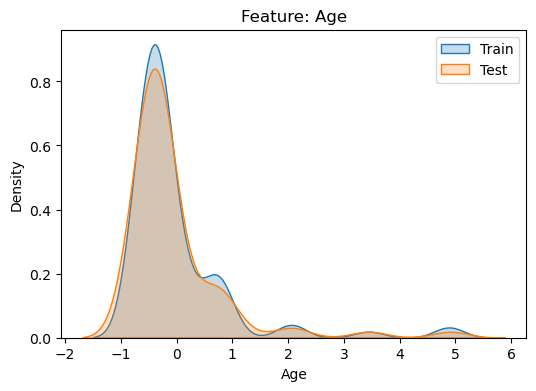

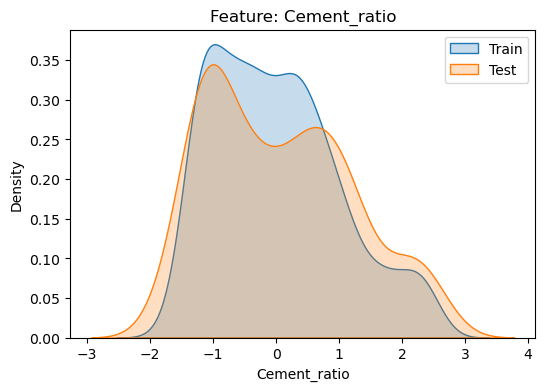

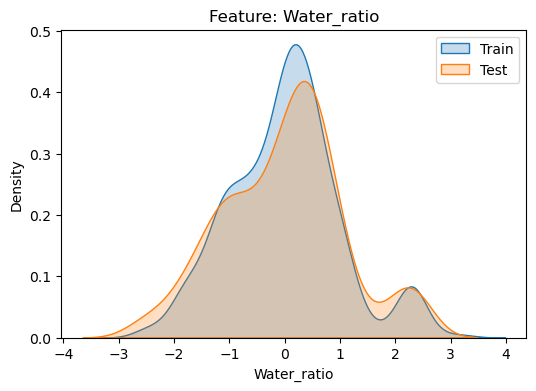

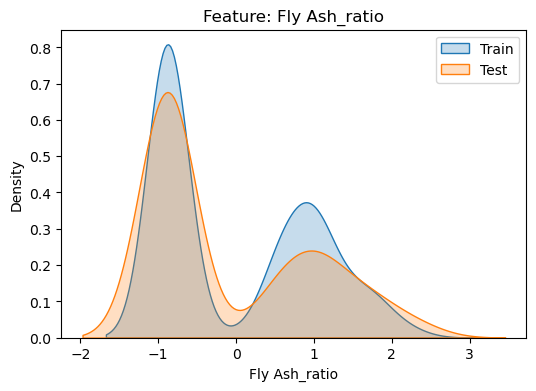

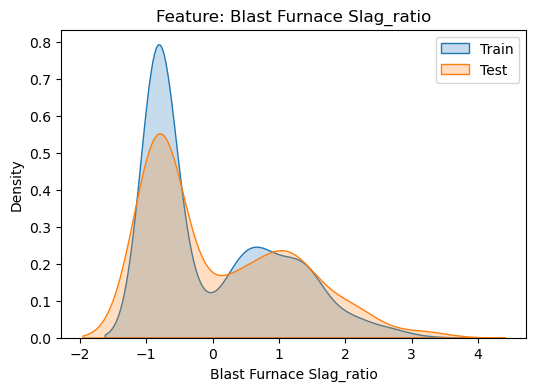

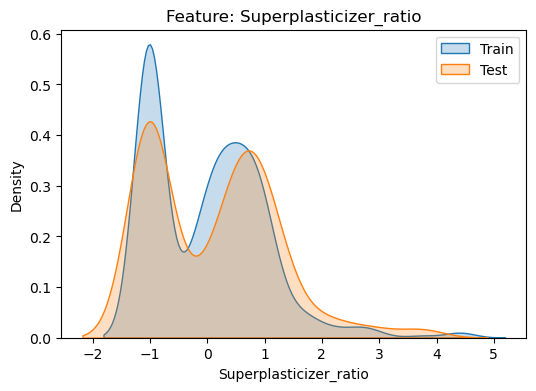

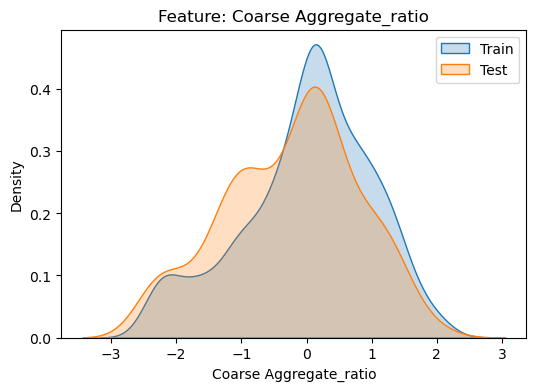

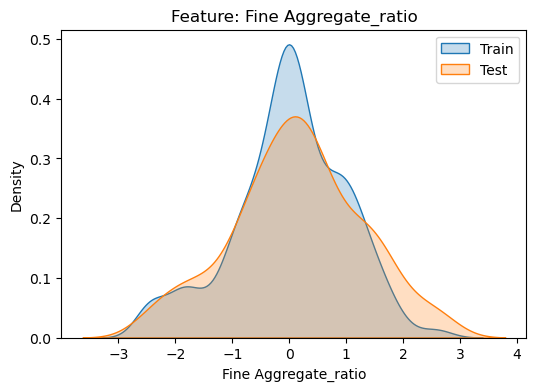

In [21]:
print("Feature Overlap in Train & Test:", x_train.columns.intersection(x_test.columns))

import matplotlib.pyplot as plt
import seaborn as sns

# Plot feature distributions
for col in x_train.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(x_train[col], label="Train", shade=True)
    sns.kdeplot(x_test[col], label="Test", shade=True)
    plt.title(f"Feature: {col}")
    plt.legend()
    plt.show()
